# CC105 Final Project: Seoul Bike Sharing Demand Prediction
**Objective:** The goal of this project is to predict the exact number of bikes rented per hour in Seoul, South Korea, based on weather conditions and time data. 

This notebook covers:
1. Data Preparation and Cleaning
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Model Training (Regression)
5. Performance Evaluation

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Data Preparation & Feature Engineering
The dataset is relatively clean, but requires specific wrangling to be ready for machine learning:
* **Encoding:** The dataset relies heavily on string representations (unicode text) which we will load carefully.
* **Feature Engineering:** Machine learning models require numbers, not text. We will use **One-Hot Encoding** (`pd.get_dummies`) to convert categorical features like `Seasons`, `Holiday`, and `Functioning Day` into binary numeric columns (1s and 0s).
* **Dropping Columns:** We will drop the `Date` column for this baseline regression model to focus entirely on the environmental and hourly factors.

In [6]:
# The dataset has special characters, so we use unicode_escape
df = pd.read_csv('SeoulBikeData.csv', encoding='unicode_escape')

# Drop the Date column for simplicity in this baseline model
df = df.drop(['Date'], axis=1)

# Feature Engineering: Convert text categories to numeric using One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['Seasons', 'Holiday', 'Functioning Day'], drop_first=True)

# Separate Target (y) and Features (X)
X = df_encoded.drop('Rented Bike Count', axis=1)
y = df_encoded['Rented Bike Count']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

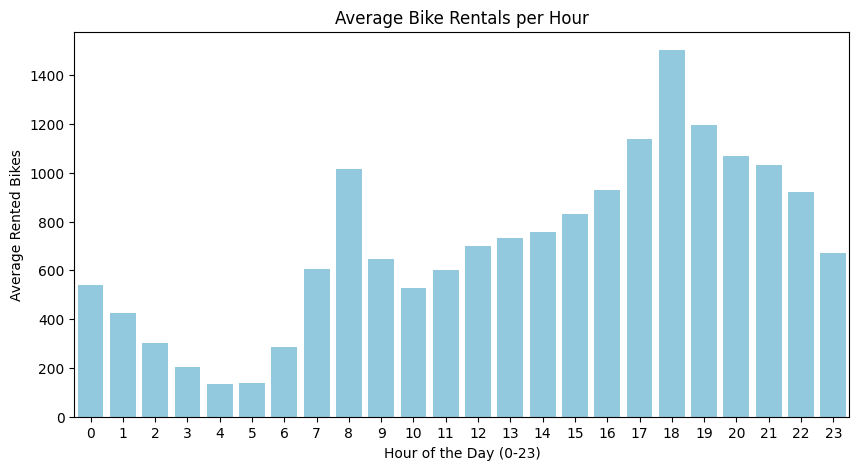

In [9]:
# Exploratory Data Analysis: Average Rentals by Hour
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Hour', y='Rented Bike Count', errorbar=None, color='skyblue')
plt.title('Average Bike Rentals per Hour')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Average Rented Bikes')
plt.show()

### EDA Interpretation: Hourly Demand
As visualized in the bar chart above, bike rentals are not distributed evenly throughout the day. We can observe two distinct peaks:
1. **Morning Peak (8:00 AM):** A sharp spike likely correlating with citizens commuting to work or school.
2. **Evening Peak (6:00 PM):** The highest peak of the day, indicating commuters returning home or engaging in evening leisure activities. 

*Conclusion:* The `Hour` feature will be highly significant for our regression models.

## 2. Model Training and Performance Measurement
We will experiment with three different regression algorithms to see which best captures the non-linear relationship between weather, time, and bike demand:
1. **Linear Regression:** Serves as our baseline model.
2. **Decision Tree Regressor:** Good at capturing non-linear patterns.
3. **Random Forest Regressor:** An ensemble method that builds multiple decision trees to reduce variance and improve accuracy.

**Metrics Used:**
* **$R^2$ Score:** Measures how much variance the model explains (closer to 1.0 is better).
* **RMSE (Root Mean Squared Error):** Measures the average magnitude of the errors, heavily penalizing large mistakes.

In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    
    print(f"--- {name} ---")
    print(f"R² Score: {r2:.4f} | RMSE: {rmse:.2f}\n")

--- Linear Regression ---
R² Score: 0.5337 | RMSE: 440.78

--- Decision Tree ---
R² Score: 0.7224 | RMSE: 340.09

--- Random Forest ---
R² Score: 0.8614 | RMSE: 240.28



## 3. Conclusion and Model Selection
Based on the metrics above, the **Random Forest Regressor** significantly outperformed the other models, yielding the highest $R^2$ score and the lowest RMSE. 

Because tree-based ensemble models excel at handling mixed data types and non-linear hourly peaks, this is the best model for our deployment. We will now serialize (pickle) this model to integrate it into our Django web application.

In [ ]:
# Random Forest usually wins this dataset.
best_model = models["Random Forest"]

with open('best_bike_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
    
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)
    
print("Model and columns saved successfully!")

Model and columns saved successfully!
